# Peramalan kadar $NO_2$ di daerah Bangkalan Madura

## Latar Belakang

Peningkatan aktivitas industri, transportasi, serta pertumbuhan populasi yang pesat telah menyebabkan peningkatan signifikan terhadap tingkat pencemaran udara di berbagai wilayah. Salah satu polutan udara utama yang menjadi perhatian adalah Nitrogen Dioksida (NO₂), yaitu gas beracun yang dihasilkan terutama dari proses pembakaran bahan bakar fosil seperti kendaraan bermotor, pembangkit listrik, dan kegiatan industri. NO₂ memiliki dampak serius terhadap kesehatan manusia, seperti gangguan pernapasan, iritasi paru-paru, serta memperburuk penyakit asma dan bronkitis. Selain itu, NO₂ juga berkontribusi terhadap pembentukan hujan asam dan penurunan kualitas lingkungan secara keseluruhan.

## 1. Pengumpulan Data

Pertama kita akan mengumpulkan data Time Series Harian kadar NO2 di daerah Bangkalan. Pengumpulan data dari sumber website https://dataspace.copernicus.eu/ , buat akun terlebih dahulu di website copernicus tersebut.

Dokumentasi cara pengambilan data di https://documentation.dataspace.copernicus.eu/notebook-samples/openeo/NO2Covid.html .

Untuk menuliskan code Python untuk mengambil data, silahkan kunjungi halaman https://dataspace.copernicus.eu/analyse/jupyterlab, klik Access JupyterLab, scroll kebawah sedikit ..., lalu pilih Python 3 (ipykernel)

![Teks alternatif](images/prediksi_no2/copernisus.png)

Disini kita akan mengambil data kadar NO2 di daerah Bangkalan dari tanggal **2024-10-01** sampai **2026-06-03** .

In [ ]:
pip install openeo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.5/345.5 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.4 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


In [ ]:
import openeo
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


Pada saat menjalankan baris code diatas (connection), nanti akan diminta authentikasi. Kalian tinggal klik link authentikasi lalu login menggunakan akun "copernicus" kalian.

Code dibawah digunakan untuk mendefinisikan area of interest (AOI) dan memuat koleksi data SENTINEL_5P_L2 untuk daerah Bangkalan:

In [ ]:
aoi = {
    "type": "Polygon",
    "coordinates": [
        [
            [113.09, -6.89],
            [112.68, -6.89],
            [112.68, -7.20],
            [113.09, -7.20],
            [113.09, -6.89],
        ]
    ]
}

s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2024-10-01", "2026-06-03"],
    spatial_extent={
        "west": 112.68,
        "south": -7.20,
        "east": 113.09,
        "north": -6.89
    },
    bands=["NO2"],
)

# Now aggregate by day to avoid having multiple data per day
s5p_no2_daily = s5post.aggregate_temporal_period(reducer="mean", period="day")

# Now create a spatial aggregation to generate mean timeseries data
s5p_no2_aoi = s5p_no2_daily.aggregate_spatial(reducer="mean", geometries=aoi)

Code diatas memerlukan titik koordinasi area yang akan diambil data $NO_2$-nya, untuk mengambil titik koordinasi kalian kunjungi website https://geojson.io/ . Didalam website tersebut kalian akan memilih daerah dengan cara memberi shape kotak didaerah yang ingin kalian ambil datanya.

Di panel sebelah kanan terdapat data JSON yang berupa koordinat daerah yang kalian pilih, kalian salin terus sesuaikan dengan code diatas di bagian variabel "aoi" dan spatial_extent.

Lalu kalian tambahkan baris code dibawah untuk memulai pengambilan data:

In [ ]:
job = s5post.execute_batch(title="NO2 in Bangkalan Terkini", outputfile="NO2Bangkalan.nc")

0:00:00 Job 'j-2606030132324265b3b08f7f1ae82297': send 'start'
0:00:19 Job 'j-2606030132324265b3b08f7f1ae82297': queued (progress 0%)
0:00:24 Job 'j-2606030132324265b3b08f7f1ae82297': queued (progress 0%)
0:00:31 Job 'j-2606030132324265b3b08f7f1ae82297': queued (progress 0%)
0:00:39 Job 'j-2606030132324265b3b08f7f1ae82297': queued (progress 0%)
0:00:49 Job 'j-2606030132324265b3b08f7f1ae82297': running (progress N/A)
0:01:01 Job 'j-2606030132324265b3b08f7f1ae82297': running (progress N/A)
0:01:17 Job 'j-2606030132324265b3b08f7f1ae82297': running (progress N/A)
0:01:36 Job 'j-2606030132324265b3b08f7f1ae82297': running (progress N/A)
0:02:00 Job 'j-2606030132324265b3b08f7f1ae82297': running (progress N/A)
0:02:30 Job 'j-2606030132324265b3b08f7f1ae82297': running (progress N/A)
0:03:08 Job 'j-2606030132324265b3b08f7f1ae82297': running (progress N/A)
0:04:13 Job 'j-2606030132324265b3b08f7f1ae82297': running (progress N/A)
0:05:11 Job 'j-2606030132324265b3b08f7f1ae82297': running (progress N

Tunggu proses pengambilan data selesai. Abaikan ketika ada N/A. Ketika proses pengambilan data, aktivitas kalian akan terekam di halaman https://editor.openeo.org/ .

![Teks alternatif](images/prediksi_no2/openeo.png)

## 2. Preproccessing Data

Setelah kita mengambil data, file akan berbentuk `.nc`. Kita cuman perlu kolom date dan NO2 menggunakan code dibawah:

In [ ]:
!pip install netCDF4

In [ ]:
import netCDF4

file_path = "NO2Bangkalan.nc"
ds = netCDF4.Dataset(file_path)

# Lihat seluruh variabel yang tersedia
print("📦 Variabel dalam file:")
print(ds.variables.keys())
# dict_keys(['t', 'x', 'y', 'crs', 'NO2'])

# Ambil NO2
no2 = ds.variables["NO2"][:]
no2_bulat = np.round(no2, decimals=2)

# Ambil Time
time = ds.variables["t"][:]

# Konversi waktu ke format tanggal jika punya atribut 'units'
try:
    time_units = ds.variables["t"].units
    dates = netCDF4.num2date(time, units=time_units)
except Exception:
    dates = time  # fallback kalau tidak ada units

# Tampilkan struktur data NO2
print(type(no2))
# type <class 'numpy.ma.core.MaskedArray'>

print(len(no2))
# banyaknya data record NO2 725

print(len(no2[0]))
# panjang data perbaris 9

print(len(no2[0][0]))
# panjang perdata 8

print(no2[0][0][0])
# 3.7701793e-05

📦 Variabel dalam file:
dict_keys(['t', 'x', 'y', 'crs', 'NO2'])
<class 'numpy.ma.MaskedArray'>
607
9
8
--


Dari code diatas kita mengetahui bentuk data dari kolom NO2 nya.

Jadi struktur data NO2 perbaris adalah `[ [[] * 8] * 9 ]`

Untuk melihat data, terdapat banyak data dengan missing value (`--`). Contoh output 200 data pertama:

In [ ]:
# Menampilkan 10 data pertama untuk koordinat [0][0]
for i in range(200):
    print(f"Data ke-{i+1} | Tanggal: {dates[i]} | NO2: {no2_bulat[i][0][0]}")

Data ke-1 | Tanggal: 2024-10-01 00:00:00 | NO2: --
Data ke-2 | Tanggal: 2024-10-02 00:00:00 | NO2: --
Data ke-3 | Tanggal: 2024-10-03 00:00:00 | NO2: --
Data ke-4 | Tanggal: 2024-10-04 00:00:00 | NO2: --
Data ke-5 | Tanggal: 2024-10-05 00:00:00 | NO2: --
Data ke-6 | Tanggal: 2024-10-06 00:00:00 | NO2: 0.0
Data ke-7 | Tanggal: 2024-10-07 00:00:00 | NO2: 0.0
Data ke-8 | Tanggal: 2024-10-08 00:00:00 | NO2: --
Data ke-9 | Tanggal: 2024-10-09 00:00:00 | NO2: 0.0
Data ke-10 | Tanggal: 2024-10-10 00:00:00 | NO2: 0.0
Data ke-11 | Tanggal: 2024-10-11 00:00:00 | NO2: 0.0
Data ke-12 | Tanggal: 2024-10-12 00:00:00 | NO2: --
Data ke-13 | Tanggal: 2024-10-13 00:00:00 | NO2: 0.0
Data ke-14 | Tanggal: 2024-10-14 00:00:00 | NO2: --
Data ke-15 | Tanggal: 2024-10-15 00:00:00 | NO2: 0.0
Data ke-16 | Tanggal: 2024-10-16 00:00:00 | NO2: 0.0
Data ke-17 | Tanggal: 2024-10-17 00:00:00 | NO2: 0.0
Data ke-18 | Tanggal: 2024-10-18 00:00:00 | NO2: 0.0
Data ke-19 | Tanggal: 2024-10-19 00:00:00 | NO2: 0.0
Data ke-20

### a. Mengatasi Missing Value menggunakan metode Interpolasi Linear

Sekarang kita akan mengatasi permasalahan missing value pada data NO2.

Dengan code dibawah, missing value yang terdapat pada data NO2 akan diisi secara otomatis menggunakan metode Interpolasi Linear.

In [ ]:
import numpy as np
import pandas as pd

# Interpolasi Linear
no2_filled = np.zeros_like(no2)
# Untuk jaga-jaga jika terdapat '--' tidak berubah menjadi 0
no2_filled = no2_filled.filled(0)

# loop tiap grid (y,x)
for i in range(no2.shape[1]):     # 9 baris
    for j in range(no2.shape[2]): # 8 kolom
        series = pd.Series(no2[:, i, j])
        no2_filled[:, i, j] = series.interpolate(method='linear', limit_direction='both').to_numpy()

### b. Rata-rata kan Data dan ubah Datetime

Setelah mengatasi missing value, kita akan me-rata-rata-kan data NO2 agar satu record hanya berupa single value. Kita juga mengubah format datetime dari `(2024-10-01 00:00:00)` menjadi `(2024-10-01)` karena kita mengambil data time series harian.

In [ ]:
new_dates = []
new_no2 = []
for i in range(len(dates)):
    # ubah format datetime
    new_date = dates[i].strftime('%Y-%m-%d')
    new_dates.append(new_date)
    new_no2.append(np.mean(no2_filled[i]))

### c. Simpan data dalam bentuk CSV

Setelah itu kita akan membentuk data menjadi DataFrame Pandas untuk disimpan menjadi CSV.

In [ ]:
df = pd.DataFrame({
    "date": new_dates,
    "NO2": new_no2
})

# Simpan ke CSV
df.to_csv("NO2_Bangkalan_timeseries.csv", index=False)

### d. Pengecekan Missing Value data harian pada CSV

Sekarang setelah data berbentuk CSV, kita cek apakah data Time Series harian lengkap:

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("NO2_Bangkalan_timeseries.csv")

# Pastikan kolom 'date' bertipe datetime
df['date'] = pd.to_datetime(df['date'])

# Buat rentang tanggal lengkap
start_date = "2024-10-01"
end_date = "2026-06-03"
full_range = pd.date_range(start=start_date, end=end_date, freq='D')

# Cek tanggal yang hilang
missing_dates = full_range.difference(df['date'])

print(f"Jumlah hari missing: {len(missing_dates)}")
print("Daftar tanggal missing:")
print(missing_dates)

Jumlah hari missing: 4
Daftar tanggal missing:
DatetimeIndex(['2025-01-30', '2025-01-31', '2026-02-24', '2026-06-03'], dtype='datetime64[ns]', freq=None)


Dalam kasus ini, terdapat **4 hari missing value**. Kita akan mengatasi lagi missing value menggunakan metode Interpolasi Linear:

In [ ]:
import pandas as pd

# Pastikan datetime dan sorting
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

# Buat rentang tanggal lengkap
full_range = pd.date_range(start="2024-10-01", end="2026-06-03", freq='D')

# Reindex agar tanggal yang hilang muncul sebagai NaN
df = df.set_index('date').reindex(full_range)
df.index.name = 'date'

# Interpolasi linear berdasarkan indeks waktu
df['NO2'] = df['NO2'].interpolate(method='time')

# (Opsional) jika masih ada NaN di bagian awal/akhir bisa gunakan forward/backward fill
df['NO2'] = df['NO2'].fillna(method='bfill').fillna(method='ffill')

# Simpan kembali ke CSV
df.to_csv("no2_timeseries_interpolated.csv")

/tmp/ipykernel_1623/2591521030.py:18: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['NO2'] = df['NO2'].fillna(method='bfill').fillna(method='ffill')


In [ ]:
import pandas as pd

# Reset index to make 'date' a column again as shown in your example
df_display = df.reset_index()

# Display the first 5 rows
display(df_display.head())

# Display the info/metadata
print("\n")
df_display.info()

        date       NO2
0 2024-10-01  0.000023
1 2024-10-02  0.000024
2 2024-10-03  0.000023
3 2024-10-04  0.000023
4 2024-10-05  0.000021




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 611 entries, 0 to 610
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    611 non-null    datetime64[ns]
 1   NO2     611 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 9.7 KB


### e. Deteksi Outlier IQR

Sekarang kita akan mendeteksi outlier menggunakan metode IQR:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("no2_timeseries_interpolated.csv")

df['date'] = pd.to_datetime(df['date'])

# Hitung IQR
Q1 = df['NO2'].quantile(0.25)
Q3 = df['NO2'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter outlier
outliers_iqr = df[(df['NO2'] < lower_bound) | (df['NO2'] > upper_bound)]

print("Jumlah Outlier (IQR):", len(outliers_iqr))
print(outliers_iqr[['date', 'NO2']].head())


Jumlah Outlier (IQR): 1
         date       NO2
16 2024-10-17  0.000047


Untuk men-visualisasi outlier:

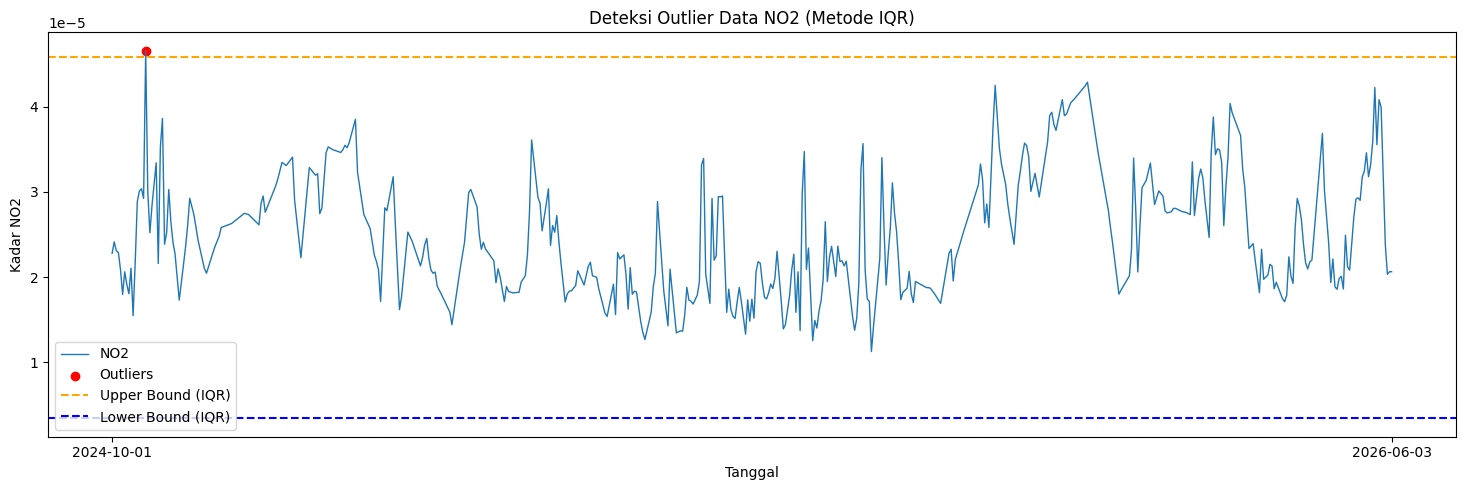

In [ ]:
# === Visualisasi ===
plt.figure(figsize=(15,5))
plt.plot(df['date'], df['NO2'], label="NO2", linewidth=1)

# Titik Outlier
plt.scatter(outliers_iqr['date'], outliers_iqr['NO2'],
            color='red', marker='o', label="Outliers")

# Garis batas atas & bawah
plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue', linestyle='dashed', label="Lower Bound (IQR)")

plt.title("Deteksi Outlier Data NO2 (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()

Setelah itu, kita akan menghapus data outlier. Karena data ini merupakan data Time Series, maka data outlier yang dihapus akan diisi kembali menggunakan Interpolasi Linear.

In [ ]:
# Tandai outlier menjadi NaN
df['NO2_cleaned'] = df['NO2'].mask((df['NO2'] < lower_bound) | (df['NO2'] > upper_bound))

print("Jumlah nilai yang dinyatakan sebagai outlier:", df['NO2_cleaned'].isna().sum())

# Interpolasi linear untuk mengisi kembali nilai outlier
df['NO2_filled'] = df['NO2_cleaned'].interpolate(method='linear')

# Jika masih tersisa NaN di ujung data, isi dengan forward/backward fill
df['NO2_filled'] = df['NO2_filled'].bfill().ffill()
# df['NO2_filled'] = df['NO2_filled'].fillna(method='bfill').fillna(method='ffill')

print("Jumlah missing setelah interpolasi:", df['NO2_filled'].isna().sum())

Jumlah nilai yang dinyatakan sebagai outlier: 1
Jumlah missing setelah interpolasi: 0


Visualisasi data setelah menghapus Outlier dan mengisi kembali menggunakan Interpolasi Linear:

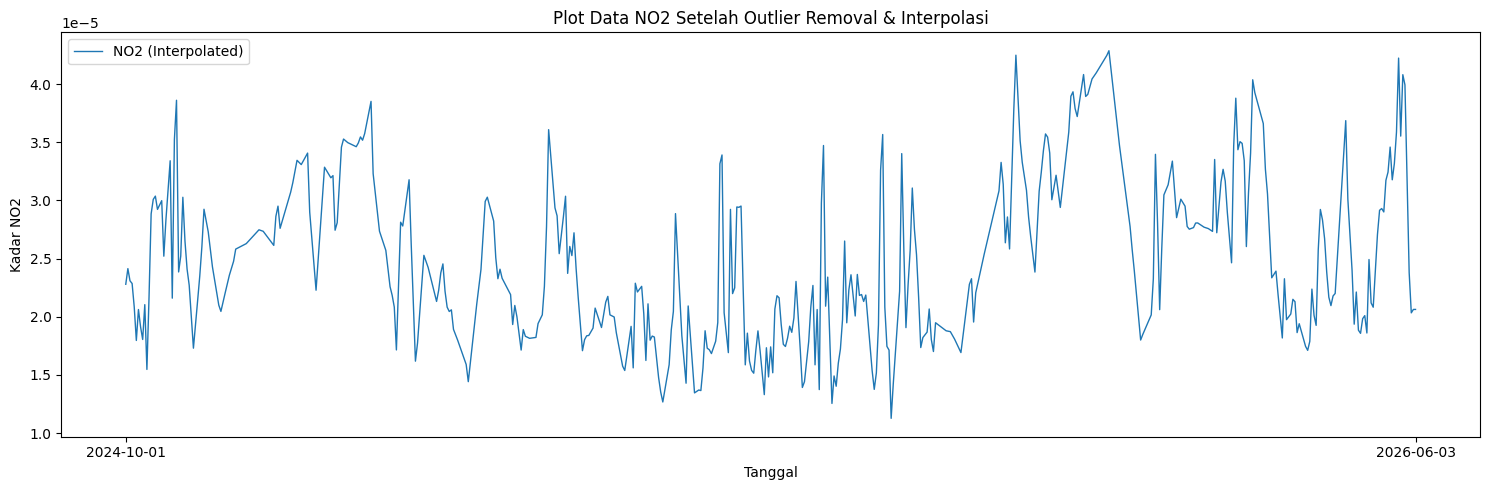

In [ ]:
plt.figure(figsize=(15,5))
# Plot data hasil interpolasi
plt.plot(df['date'], df['NO2_filled'], label="NO2 (Interpolated)", linewidth=1)
# Tampilkan hanya tanggal awal dan akhir di sumbu X
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.title("Plot Data NO2 Setelah Outlier Removal & Interpolasi")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.show()

## 3. Modeling menggunakan KNN Regression

Dengan data Time Series kadar NO2 harian di daerah Bangkalan, kita akan memprediksi kadar NO2 satu hari yang akan datang. Sekarang kita akan ubah data, mencoba mencari korelasi antara 1 hari dengan hari-hari sebelumnya.

### a. Uji Korelasi Data

Sebelum masuk ke modeling, kita ubah data dari unsupervised menjadi supervised lalu uji korelasi terhadap label (t). Fitur-fiturnya merupakan 30 hari sebelum (t-30, t-29, ... t-1) dan label (t).

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# 1. Scaling data terlebih dahulu
scaler = MinMaxScaler()
df['NO2_scaled'] = scaler.fit_transform(df[['NO2_filled']])

def create_supervised(data, n_lag=4):
    df_supervised = pd.DataFrame()

    # Membuat fitur t-n sampai t-1
    for i in range(n_lag, 0, -1):
        df_supervised[f'NO2(t-{i})'] = data.shift(i)

    # Label hari H
    df_supervised['NO2(t)'] = data

    # Hapus baris yang masih mengandung NaN akibat shift
    df_supervised.dropna(inplace=True)

    return df_supervised

# 2. Pembuatan dataset supervised
supervised_df30 = create_supervised(df['NO2_scaled'], n_lag=30)

# Ambil semua lag dan kolom target
lag_cols = supervised_df30.drop(columns="NO2(t)").columns
correlations = supervised_df30[lag_cols].corrwith(supervised_df30['NO2(t)'])

# Tampilkan nilai korelasi
print(correlations)

NO2(t-30)    0.313437
NO2(t-29)    0.333162
NO2(t-28)    0.355497
NO2(t-27)    0.354278
NO2(t-26)    0.340605
NO2(t-25)    0.325570
NO2(t-24)    0.310233
NO2(t-23)    0.304656
NO2(t-22)    0.304531
NO2(t-21)    0.304638
NO2(t-20)    0.304368
NO2(t-19)    0.310469
NO2(t-18)    0.320158
NO2(t-17)    0.334370
NO2(t-16)    0.350005
NO2(t-15)    0.364408
NO2(t-14)    0.382672
NO2(t-13)    0.400678
NO2(t-12)    0.413531
NO2(t-11)    0.442313
NO2(t-10)    0.483143
NO2(t-9)     0.509766
NO2(t-8)     0.533202
NO2(t-7)     0.547421
NO2(t-6)     0.566128
NO2(t-5)     0.601998
NO2(t-4)     0.649300
NO2(t-3)     0.717091
NO2(t-2)     0.799373
NO2(t-1)     0.903598
dtype: float64


Skala nilai uji korelasi itu dari -1 sampai 1. Dari hasil diatas, nilai uji korelasi terbaik (lebih dari 0.5) adalah fitur **t-1 sampai t-4**.

### b. Normalisasi Data

Karena kita menggunakan model KNN Regression, maka perlu normalisasi data menggunakan Min-Max Scaler.

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

scaler = MinMaxScaler()

df['NO2_scaled'] = scaler.fit_transform(df[['NO2']])

In [ ]:
# Menampilkan data yang sudah dinormalisasi
display(df[['date', 'NO2', 'NO2_scaled']].head())
print("\n")
df.info()

        date       NO2  NO2_scaled
0 2024-10-01  0.000023    0.326641
1 2024-10-02  0.000024    0.364727
2 2024-10-03  0.000023    0.335015
3 2024-10-04  0.000023    0.328510
4 2024-10-05  0.000021    0.271637




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 611 entries, 0 to 610
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         611 non-null    datetime64[ns]
 1   NO2          611 non-null    float64       
 2   NO2_cleaned  610 non-null    float64       
 3   NO2_filled   611 non-null    float64       
 4   NO2_scaled   611 non-null    float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 24.0 KB


Maka data akan di-normalisasi 0-1.

### c. Mengubah Data

Sekarang kita ubah data menjadi supervised dengan 4 hari sebelumnya (t-4, t-3, t-2, t-1, dan t sebagai label) karena dari uji korelasi, keempat fitur tersebut merupakan nilai korelasi terbaik (lebih dari 0.5). Kita juga membuat data 10 hari sebelum untuk perbandingan.

In [ ]:
supervised_df = create_supervised(df['NO2_scaled'], n_lag=4)

print(supervised_df)
print(supervised_df.shape)

     NO2(t-4)  NO2(t-3)  NO2(t-2)  NO2(t-1)    NO2(t)
4    0.326641  0.364727  0.335015  0.328510  0.271637
5    0.364727  0.335015  0.328510  0.271637  0.189721
6    0.335015  0.328510  0.271637  0.189721  0.265051
7    0.328510  0.271637  0.189721  0.265051  0.222921
8    0.271637  0.189721  0.265051  0.222921  0.192101
..        ...       ...       ...       ...       ...
606  0.877560  0.687542  0.837156  0.812341  0.578370
607  0.687542  0.837156  0.812341  0.578370  0.355028
608  0.837156  0.812341  0.578370  0.355028  0.256983
609  0.812341  0.578370  0.355028  0.256983  0.265315
610  0.578370  0.355028  0.256983  0.265315  0.265315

[607 rows x 5 columns]
(607, 5)


In [ ]:
supervised_df10 = create_supervised(df['NO2_scaled'], n_lag=10)

print(supervised_df10)
print(supervised_df10.shape)

     NO2(t-10)  NO2(t-9)  NO2(t-8)  NO2(t-7)  NO2(t-6)  NO2(t-5)  NO2(t-4)  \
10    0.326641  0.364727  0.335015  0.328510  0.271637  0.189721  0.265051   
11    0.364727  0.335015  0.328510  0.271637  0.189721  0.265051  0.222921   
12    0.335015  0.328510  0.271637  0.189721  0.265051  0.222921  0.192101   
13    0.328510  0.271637  0.189721  0.265051  0.222921  0.192101  0.276935   
14    0.271637  0.189721  0.265051  0.222921  0.192101  0.276935  0.119160   
..         ...       ...       ...       ...       ...       ...       ...   
606   0.579870  0.599825  0.660784  0.581097  0.620900  0.697317  0.877560   
607   0.599825  0.660784  0.581097  0.620900  0.697317  0.877560  0.687542   
608   0.660784  0.581097  0.620900  0.697317  0.877560  0.687542  0.837156   
609   0.581097  0.620900  0.697317  0.877560  0.687542  0.837156  0.812341   
610   0.620900  0.697317  0.877560  0.687542  0.837156  0.812341  0.578370   

     NO2(t-3)  NO2(t-2)  NO2(t-1)    NO2(t)  
10   0.222921  0.

### d. Modeling dan Evaluation

Sekarang dari 2 data yang sudah kita rubah, kita train menggunakan model KNN Regression.

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

def MAPE(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Hindari pembagian dengan nol
    nonzero = y_true != 0
    return np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100

def train_knn(df_supervised, model_name=""):
    # Pisahkan fitur & label
    X = df_supervised.drop(columns=['NO2(t)']).values
    y = df_supervised['NO2(t)'].values

    # Split data 80/20
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=False
    )

    # Model KNN
    knn = KNeighborsRegressor(n_neighbors=5)
    knn.fit(X_train, y_train)

    # Prediksi
    y_pred = knn.predict(X_test)

    # Evaluasi
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    mape = MAPE(y_test, y_pred)

    print(f"\n=== {model_name} ===")
    print(f"Train Size: {len(X_train)} — Test Size: {len(X_test)}")
    print(f"RMSE: {rmse:.6f}")
    print(f"R² Score: {r2:.4f}")
    print(f"MAPE: {mape:.4f}%")

    return knn, y_test, y_pred


# Train model untuk 4 hari sebelumnya
knn_4, y_test_4, y_pred_4 = train_knn(supervised_df, "KNN - 4 Hari Sebelumnya")

# Train model untuk 10 hari sebelumnya
knn_10, y_test_10, y_pred_10 = train_knn(supervised_df10, "KNN - 10 Hari Sebelumnya")


=== KNN - 4 Hari Sebelumnya ===
Train Size: 485 — Test Size: 122
RMSE: 0.099469
R² Score: 0.6726
MAPE: 17.2213%

=== KNN - 10 Hari Sebelumnya ===
Train Size: 480 — Test Size: 121
RMSE: 0.106538
R² Score: 0.6236
MAPE: 20.0261%


Berdasarkan hasil akurasi diatas:
- **KNN - 4 Hari Sebelumnya**: RMSE = 0.099469, R² = 0.6726, MAPE = 17.2213%
- **KNN - 10 Hari Sebelumnya**: RMSE = 0.106538, R² = 0.6236, MAPE = 20.0261%

Terlihat bahwa model dengan 4 hari sebelumnya memberikan performa lebih baik. Kita coba gunakan data 30 hari sebelumnya juga untuk melihat apakah semakin banyak hari sebelumnya, model semakin baik?

### e. Plotting

Plotting untuk visualisasi grafik antara label dan prediksi.

4 hari sebelum:

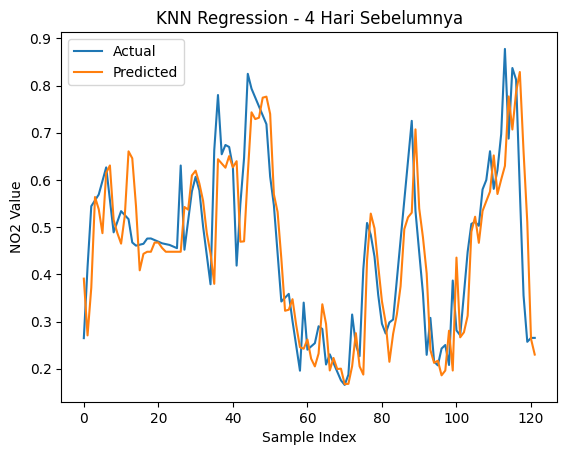

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure()
plt.plot(np.arange(len(y_test_4)), y_test_4, label="Actual")
plt.plot(np.arange(len(y_pred_4)), y_pred_4, label="Predicted")
plt.title("KNN Regression - 4 Hari Sebelumnya")
plt.xlabel("Sample Index")
plt.ylabel("NO2 Value")
plt.legend()
plt.show()

10 hari sebelum:

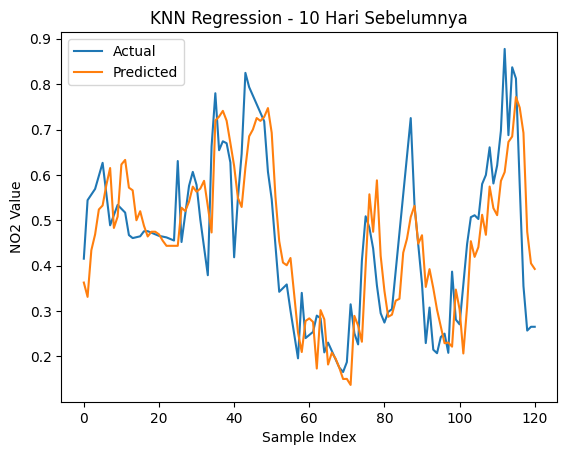

In [ ]:
plt.figure()
plt.plot(np.arange(len(y_test_10)), y_test_10, label="Actual")
plt.plot(np.arange(len(y_pred_10)), y_pred_10, label="Predicted")
plt.title("KNN Regression - 10 Hari Sebelumnya")
plt.xlabel("Sample Index")
plt.ylabel("NO2 Value")
plt.legend()
plt.show()

30 hari sebelum:


=== KNN - 30 Hari Sebelumnya ===
Train Size: 464 — Test Size: 117
RMSE: 0.164701
R² Score: 0.2965
MAPE: 31.8232%


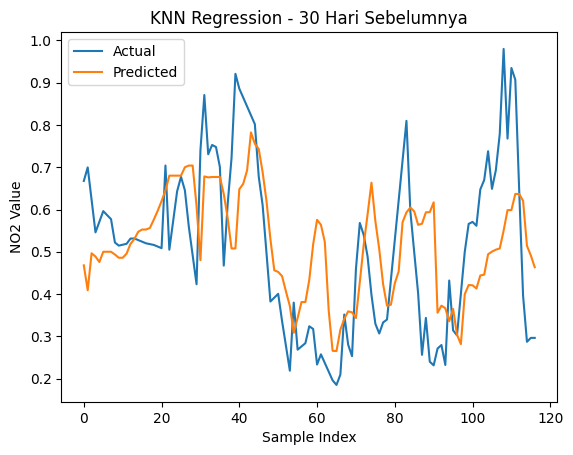

In [ ]:
# Train model untuk 30 hari sebelumnya
knn_30, y_test_30, y_pred_30 = train_knn(supervised_df30, "KNN - 30 Hari Sebelumnya")

# Plotting hasil 30 hari
plt.figure()
plt.plot(np.arange(len(y_test_30)), y_test_30, label="Actual")
plt.plot(np.arange(len(y_pred_30)), y_pred_30, label="Predicted")
plt.title("KNN Regression - 30 Hari Sebelumnya")
plt.xlabel("Sample Index")
plt.ylabel("NO2 Value")
plt.legend()
plt.show()

Hasil evaluasi model KNN Regression menunjukkan bahwa peningkatan jumlah fitur historis (lag) tidak serta merta meningkatkan performa prediksi. Pada model dengan 4 hari sebelumnya, nilai RMSE paling kecil (0.099469) dan R² = 0.6726 sehingga model mampu menjelaskan sebagian variabilitas data target dengan cukup baik. Namun, ketika jumlah lag ditambah menjadi 10 dan 30 hari sebelumnya, performa model justru menurun yang ditunjukkan oleh meningkatnya nilai RMSE dan MAPE, serta penurunan nilai R².

Secara keseluruhan, model KNN dengan 4 hari sebelumnya memberikan performa terbaik pada data ini dengan MAPE 17.22%. Penambahan fitur historis lebih banyak justru menyebabkan penurunan kemampuan generalisasi model.